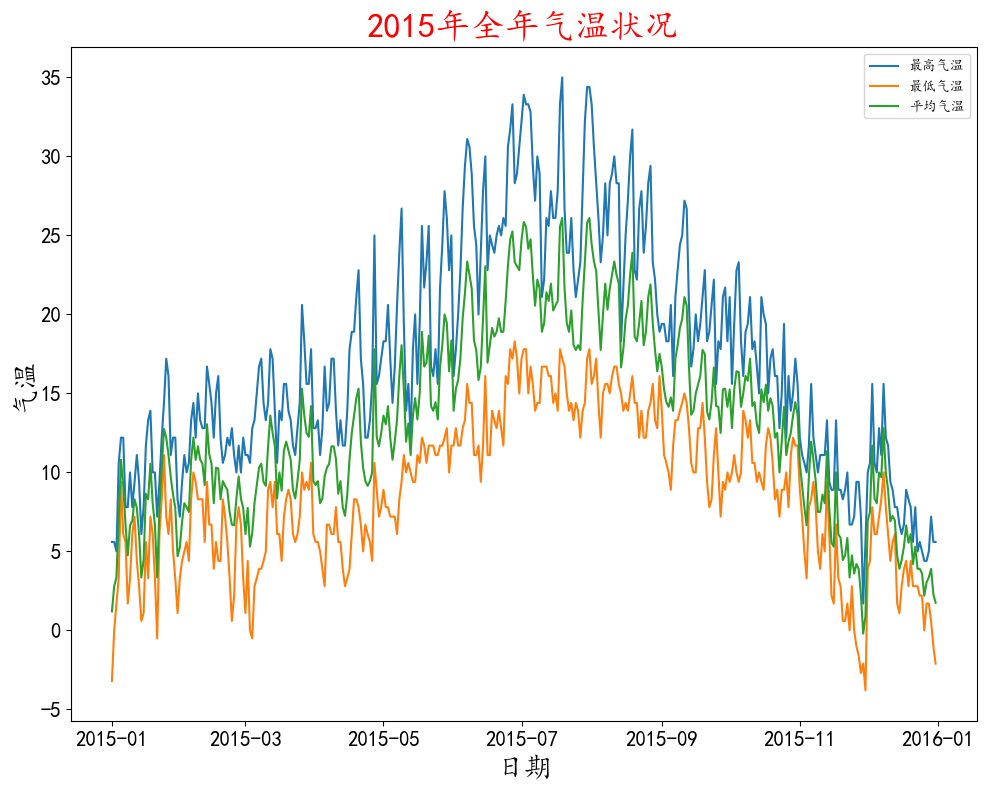

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] ='kaiti'

#尺寸大小
plt.figure(figsize =(10,8))

#导入数据
df = pd.read_csv(r'D:\py-90-day\数据分析\data\weather.csv')
df['date'] = pd.to_datetime(df['date'])

#绘制气温的趋势变化图

df = df[df['date'].dt.year==2015]
plt.plot(df['date'],df['temp_max'],label = '最高气温')
plt.plot(df['date'],df['temp_min'],label = '最低气温')
plt.xlabel('日期',fontsize= 20)
plt.ylabel('气温',fontsize = 20)     #标签
plt.xticks(rotation = 0,fontsize =15)   #横坐标数值的角度，大小
plt.yticks(rotation = 0,fontsize =15)
df['temp_mean'] = (df['temp_max']+df['temp_min'])/2
plt.plot(df['date'],df['temp_mean'],label = '平均气温')
plt.legend(loc = 'upper right')  #图表案例
plt.title('2015年全年气温状况',color = 'red',fontsize = 25)

#显示图表
plt.tight_layout()
plt.show()

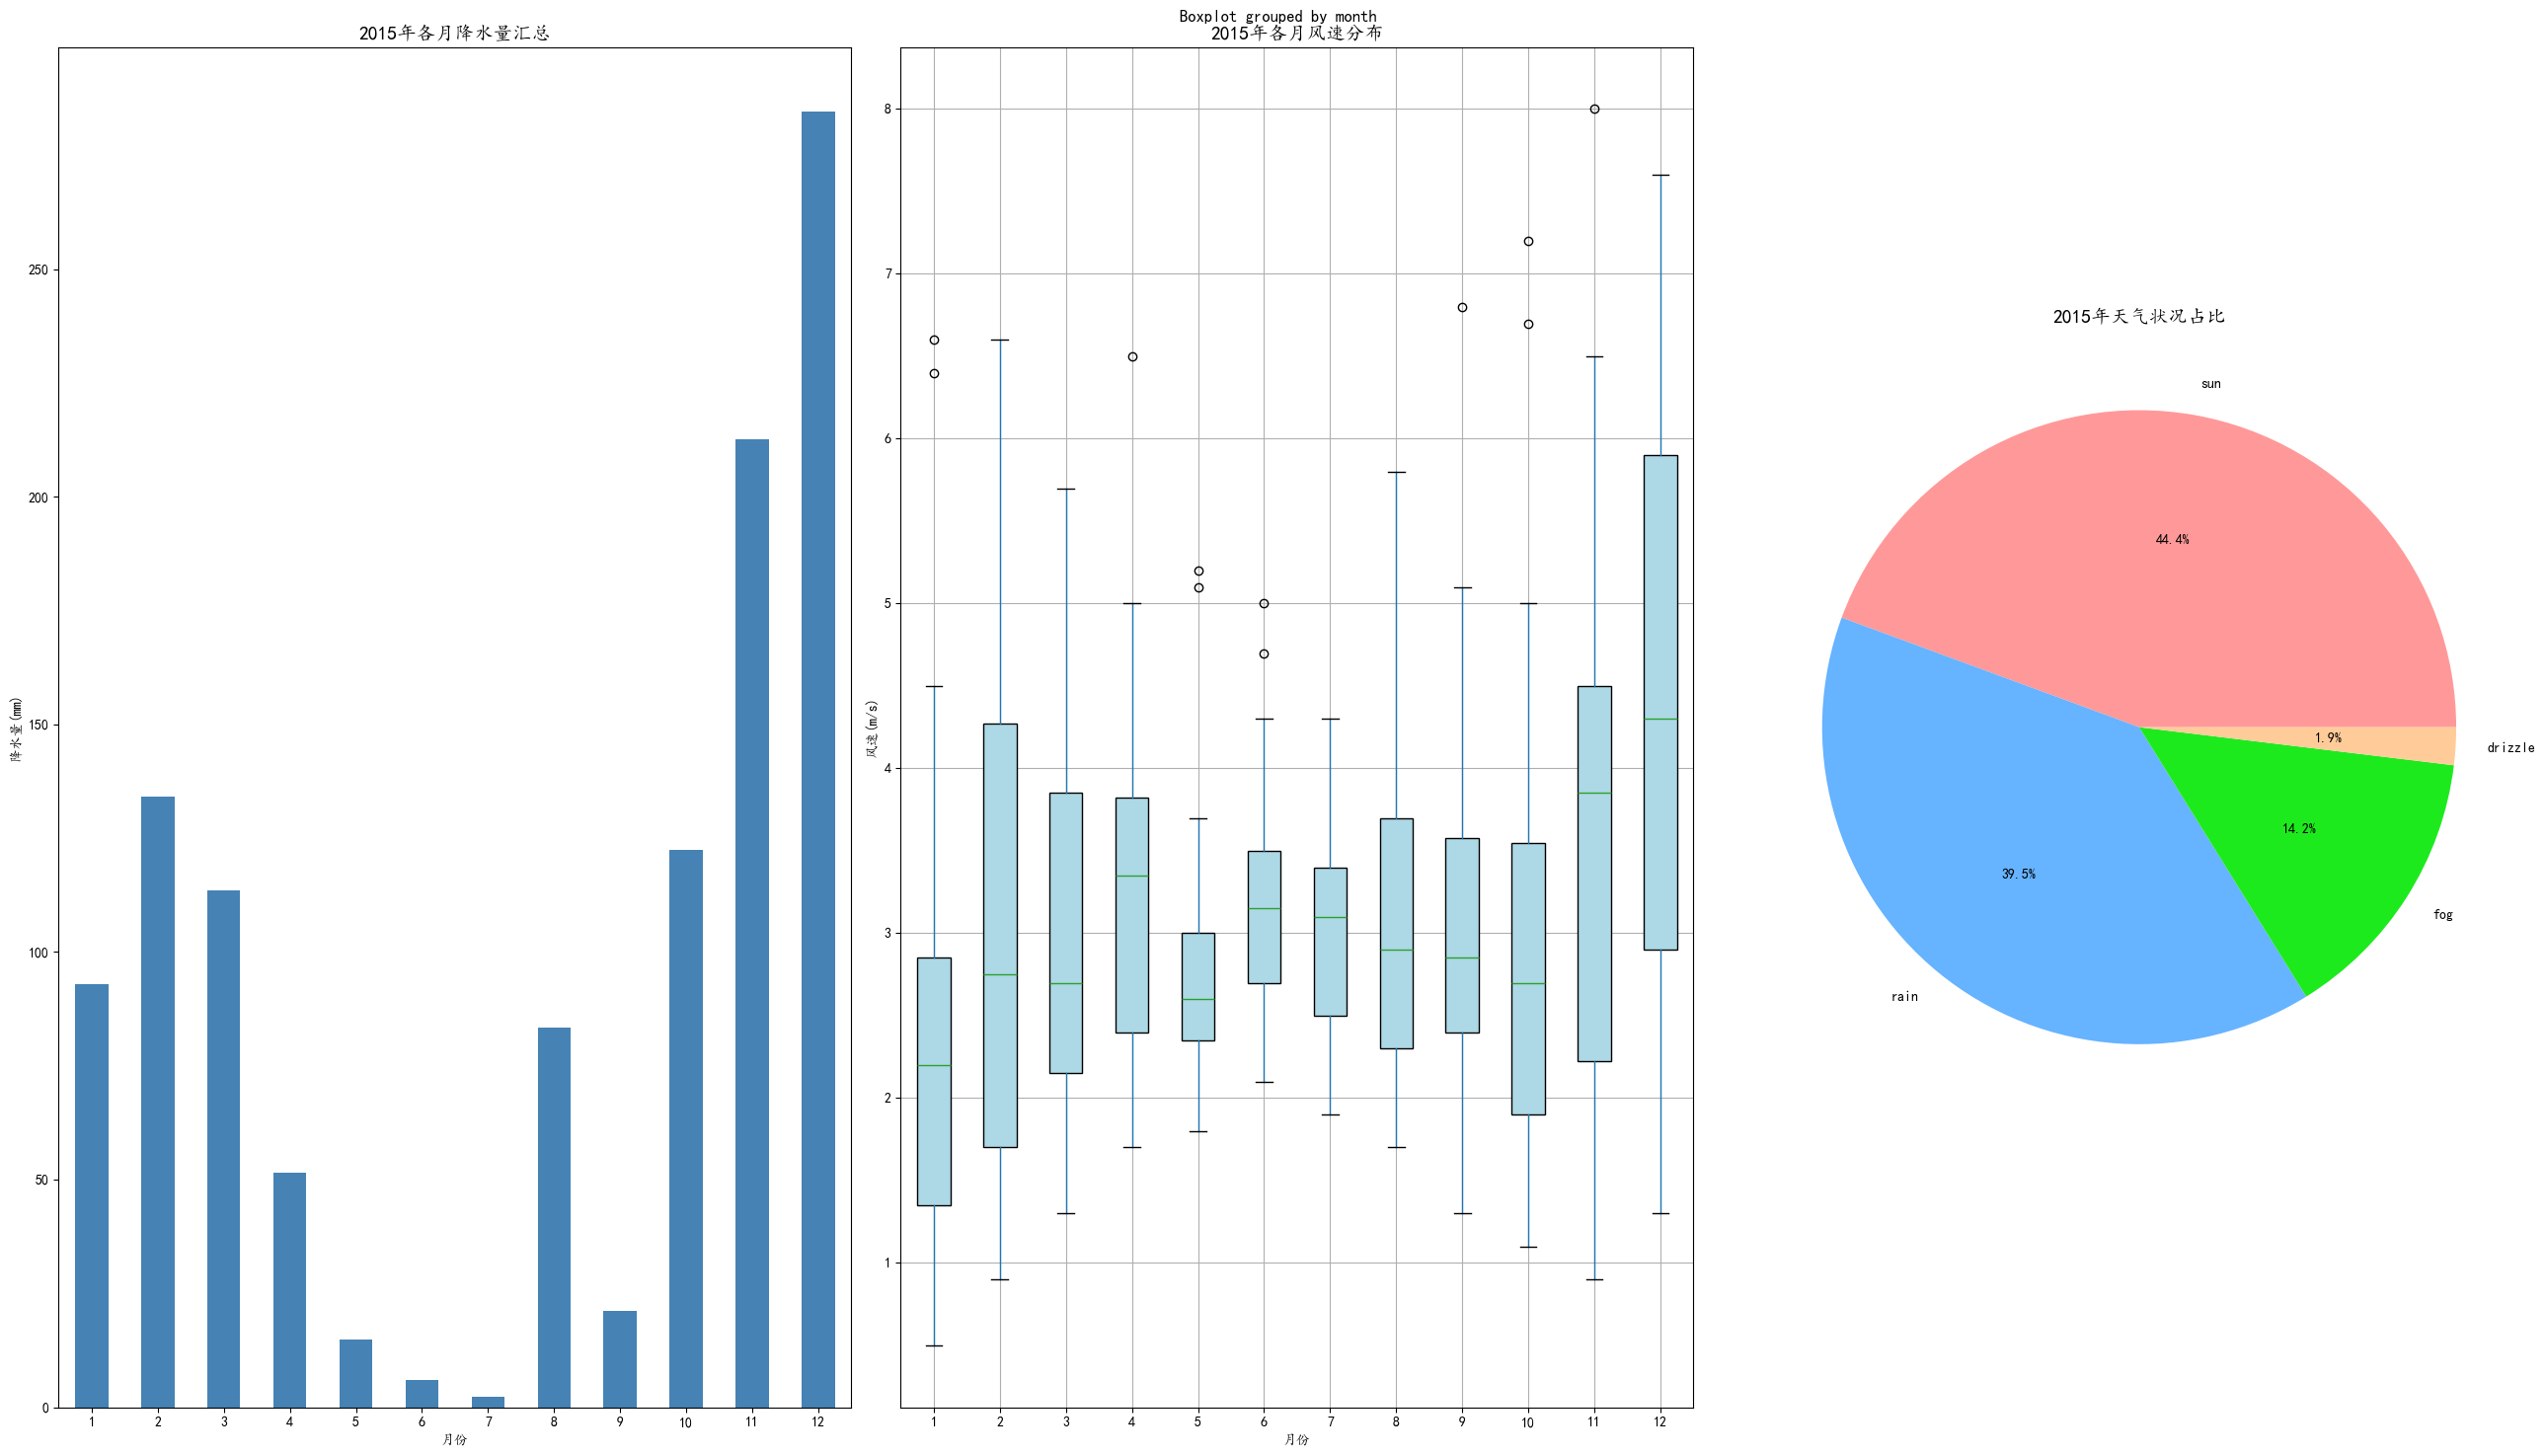

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'kaiti'          # 中文字体
plt.rcParams['axes.unicode_minus'] = False # 负号正常显示

# 1. 读数据
df = pd.read_csv(r'D:\py-90-day\数据分析\data\weather.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'].dt.year == 2015]

# 2. 构造月份字段，方便后续按月聚合
df['month'] = df['date'].dt.month

# 3. 一页三图
fig = plt.figure(figsize=(26,15))

# -------- 3.1 降水柱状图 --------
ax1 = fig.add_subplot(131)
month_rain = df.groupby('month')['precipitation'].sum()  # 按月汇总
month_rain.plot(kind='bar', color='steelblue', ax=ax1)
ax1.set_title('2015年各月降水量汇总', fontsize=14)
ax1.set_xlabel('月份')
ax1.set_ylabel('降水量(mm)')
ax1.tick_params(axis='x', rotation=0)

# -------- 3.2 风速箱线图 --------
ax2 = fig.add_subplot(132)
df.boxplot(column='wind', by='month', ax=ax2, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax2.set_title('2015年各月风速分布', fontsize=14)
ax2.set_xlabel('月份')
ax2.set_ylabel('风速(m/s)')
ax2.tick_params(axis='x', rotation=0)

# -------- 3.3 天气状况饼图 --------
ax3 = fig.add_subplot(133)
weather_cnt = df['weather'].value_counts()
ax3.pie(weather_cnt.values, labels=weather_cnt.index, autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff',"#1DEA1D",'#ffcc99','#ff99cc'])
ax3.set_title('2015年天气状况占比', fontsize=14)

plt.tight_layout()
plt.show()

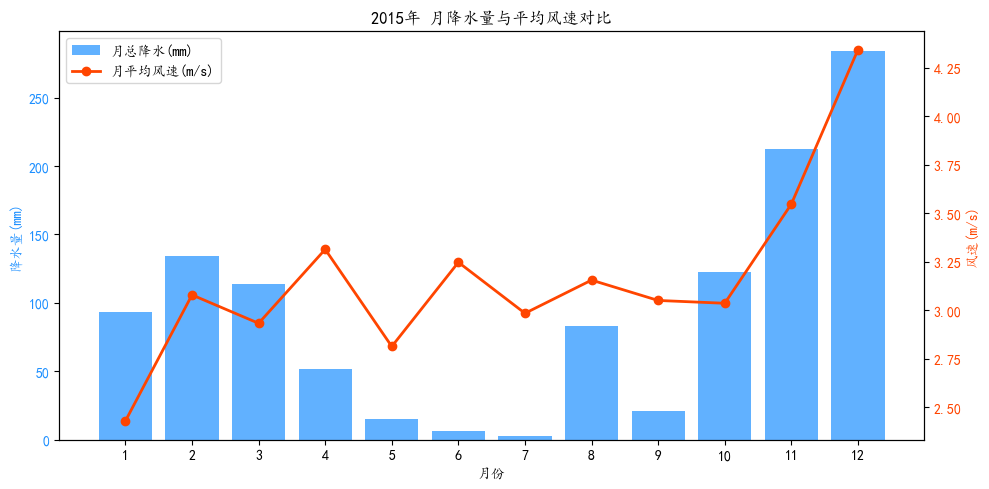

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'kaiti'
plt.rcParams['axes.unicode_minus'] = False

# 1. 读数据并筛选 2015
df = pd.read_csv(r'D:\py-90-day\数据分析\data\weather.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'].dt.year == 2015]
df['month'] = df['date'].dt.month

# 2. 按月聚合：降水总量、平均风速
month_stat = df.groupby('month').agg(
    总降水=('precipitation', 'sum'),
    平均风速=('wind', 'mean')
)

# 3. 画图
fig, ax1 = plt.subplots(figsize=(10, 5))

# 3.1 柱形图：降水（左侧 Y 轴）
bars = ax1.bar(month_stat.index, month_stat['总降水'],
               color='dodgerblue', alpha=0.7, label='月总降水(mm)')
ax1.set_xlabel('月份')
ax1.set_ylabel('降水量(mm)', color='dodgerblue')
ax1.tick_params(axis='y', labelcolor='dodgerblue')

# 3.2 折线图：平均风速（右侧 Y 轴）
ax2 = ax1.twinx()                        # 复制一根同 X 轴的右侧 Y 轴
ax2.plot(month_stat.index, month_stat['平均风速'],
         color='orangered', marker='o', linewidth=2, label='月平均风速(m/s)')
ax2.set_ylabel('风速(m/s)', color='orangered')
ax2.tick_params(axis='y', labelcolor='orangered')

# 3.3 图例合并
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 3.4 标题与细节
plt.title('2015年 月降水量与平均风速对比')
ax1.set_xticks(range(1, 13))
fig.tight_layout()
plt.show()